In [10]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

from funciones_modelado import metricas, obtener_fold


# B0
El B0 supone que el ratio = 1. ERP acierta.    

Este no se entrena, predice 1 para todas las fases. Lo que hay que hacer es medir su error en los mismos datos donde mediremos los modelos.   
Trabajaremos con las dos metricas de error, MAE y RMSE para evaluar la diferencia. 

> Interesa medir cuánto se equivoca esa regla en validación. 

In [11]:
df_B0 = pd.read_parquet("datos/df_split.parquet")   

In [12]:
# Predicción de B0: ratio = 1 para todas las fases (el tiempo real = el teórico)
df_B0["pred_B0"] = 1.0

# Meses de validación, leídos del archivo común
folds = pd.read_csv("datos/folds.csv", dtype=str)
MESES_VALIDACION = folds["mes_validacion"].tolist()      # ['2026-02', '2026-03', '2026-04']

# Error de B0 en cada mes de validación
filas = []
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df_B0, mes)              # B0 no entrena: solo usamos valid
    filas.append({"bloque": f"valid {mes}", **metricas(valid["ratio"], valid["pred_B0"])})

# Error de B0 en test   
t = df_B0[df_B0["split"] == "test"]
filas.append({"bloque": "TEST", **metricas(t["ratio"], t["pred_B0"])})

# Tabla de resultados
resultados_B0 = pd.DataFrame(filas).round(3)
print(resultados_B0)

          bloque    MAE   RMSE     n
0  valid 2026-02  1.144  1.794   919
1  valid 2026-03  1.083  1.669   997
2  valid 2026-04  1.099  1.696   971
3           TEST  1.020  1.590  2396


Los resultados son estables entre meses, además los valores de MAE y RMSE son notablemente altos.

- MAE     
Se mantiene en torno al 1,1. Esto supone que de media el tiempo real se aleja del teórico en un 110% del tiempo teórico (en una fase de 60 min, unos ±66 min). El MAE no tiene signo, así que no indica si el ERP se queda corto o se pasa. Conectando con la revisión del ratio donde se vieron ratios de hasta 8 unidades, podria ser que ERP se este quedando corto en sus tiempos teoricos, pero no se puede confirmar todavia.

- RMSE     
Se mantiene en torno al 1,6. Su valor es mayor que el de MAE, RMSE es sensible a fallos grandes, esto indica que los tiempos teóricos contienen errores grandes. El RMSE no se lee como una desviación media, lo útil es compararlo con el MAE.

La separación entre MAE y RMSE remarca el hecho de que hay errores grandes en la planificación, podemos entender esto como que el error no es homogéneo: hay fases que se equivocan poco y algunas que se equivocan mucho. Esto encaja con el estudio de las colas del ratio, donde un grupo de fases mantenía valores muy altos sin ser outliers.

Estos resultados hay que mirarlos con profundidad. Un MAE alto puede deberse a dos cosas: sesgo o dispersión en la planificación.

> ¿El error de B0 es sesgo o dispersión?

In [13]:
filas = []
bloques = [(f"valid {mes}", obtener_fold(df_B0, mes)[1]) for mes in MESES_VALIDACION]
bloques.append(("TEST", df_B0[df_B0["split"] == "test"]))

for nombre, d in bloques:
    filas.append({
        "bloque":               nombre,
        "error_medio":          (d["pred_B0"] - d["ratio"]).mean(), 
        "mediana_ratio":        d["ratio"].median(),
        "%_ratio>1":            (d["ratio"] > 1).mean() * 100,
        "media_ratio":          (d["ratio"].mean()),
        "diferencia":           (d["ratio"].mean()-d["ratio"].median())
    })

sesgo_B0 = pd.DataFrame(filas).round(3)
print(sesgo_B0)

          bloque  error_medio  mediana_ratio  %_ratio>1  media_ratio  \
0  valid 2026-02       -1.012          1.535     74.973        2.012   
1  valid 2026-03       -0.957          1.579     78.937        1.957   
2  valid 2026-04       -0.948          1.537     74.768        1.948   
3           TEST       -0.885          1.489     75.250        1.885   

   diferencia  
0       0.477  
1       0.378  
2       0.411  
3       0.396  


Estos resultados apunta a un sesgo, ERP se queda corto en sus estimaciones de tiempo. Aproximadamente el 75% de las fases tienen un ratio superior a 1,  3 de cada 4 fases tardan más de lo planificado. La mediana con un ratio de 1,5 indica que el tiempo práctico de una fase tipica supera un 50% al teorico. El error medio se ha calculando como ratio_ERP - ratio_Real, qye este se mantenga en torno al -0,9 refuerza que haya un sesgo hacia un tiempo teorico menor al práctico. Estos resultados son estables en el tiempo. 

Analizando la relación entre la media y la mediana del ratio se aprecia que la media queda claramente por encima de la mediana en todos los bloques, unos 0,4 puntos sobre el ratio. Comom ya se detecto al estudiar el ratio, la distribución del ratio es asimétrica, con cola a la derecha. Hay un grupo de fases con ratios muy altos que tira de la media hacia arriba. La asimetria es estable en todos los bloques. 

El hecho que la diferencia sea positiva puede ser un indicio de tener una cola hacia la derecha. Encaja con lo que se vio al analizar el ratio en `8.Variable_Objetivo`. 

Dado la naturaleza multiplicativa del ratio, voy a proceder a explorar los mismos resultados pero con el **log(ratio)**

In [14]:
filas = []
bloques = [(f"valid {mes}", obtener_fold(df_B0, mes)[1]) for mes in MESES_VALIDACION]
bloques.append(("TEST", df_B0[df_B0["split"] == "test"]))

for nombre, d in bloques:
    log_ratio = np.log(d["ratio"])
    filas.append({
        "bloque":              nombre,
        "error_medio_log":     (0 - log_ratio).mean(),
        "mediana_log":         log_ratio.median(),
        "%_log>0":             (log_ratio > 0).mean() * 100,
        "media_log":           log_ratio.mean(),
        "diferencia_log":      log_ratio.mean() - log_ratio.median(),
    })

sesgo_B0_log = pd.DataFrame(filas).round(3)
print(sesgo_B0_log)

          bloque  error_medio_log  mediana_log  %_log>0  media_log  \
0  valid 2026-02           -0.470        0.429   74.973      0.470   
1  valid 2026-03           -0.467        0.457   78.937      0.467   
2  valid 2026-04           -0.443        0.430   74.768      0.443   
3           TEST           -0.430        0.398   75.250      0.430   

   diferencia_log  
0           0.042  
1           0.010  
2           0.013  
3           0.032  


Revisando las mismas métricas el comportamiento es estable entre bloques, igual que en escala ratio, aún así con el logaritmo del ratio se aprecian cambios. Concretamente la media y la mediana convergen. Su diferencia es mínima en comparación con los resultados del ratio sin logaritmo. Esto apunta a que el log(ratio) es mucho más simétrico que el ratio, algo que ya se vio en el notebook `8.Variable_Objetivo`.

Estos datos apoyan incluirlo en los experimentos, aunque la cercanía entre media y mediana es un indicio de simetría, no una prueba completa.

Cabe destacar que esta notable simetría en la escala del logaritmo hace pensar que las desviaciones son de tipo multiplicativo. Entendiendo como desviación la diferencia entre real y teórico.

Entonces aquí lo que vemos es que el log altera la escala en la que se miden las desviaciones, y en esta escala se comportan de una forma más simétrica. Aun así, el sesgo sigue presente: el 75% de las fases mantiene log(ratio) > 0. El log cambia la forma de la distribución, pero no elimina el sesgo.

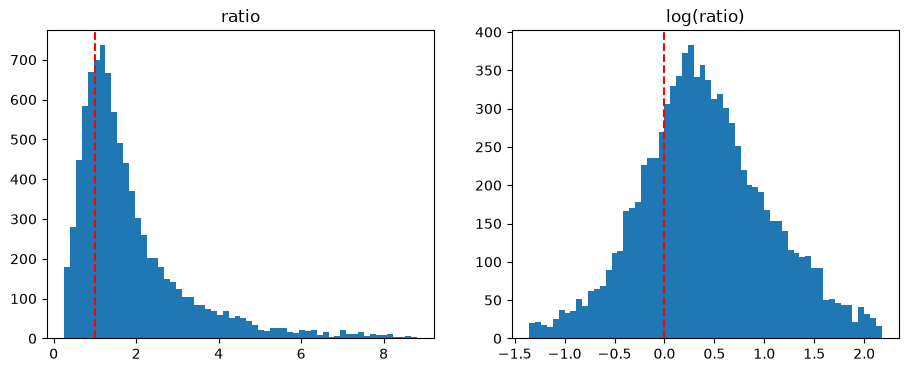

Asimetría ratio:      1.97
Asimetría log(ratio): 0.14


In [15]:
train_f1, _ = obtener_fold(df_B0, MESES_VALIDACION[0])     # train del fold 1 (jun 2025 – ene 2026)

ratio = train_f1["ratio"]
log_ratio = np.log(ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(ratio, bins=60)
ax1.set_title("ratio")
ax1.axvline(1, color="red", ls="--")

ax2.hist(log_ratio, bins=60)
ax2.set_title("log(ratio)")
ax2.axvline(0, color="red", ls="--")
plt.show()

print("Asimetría ratio:     ", round(ratio.skew(), 2))
print("Asimetría log(ratio):", round(log_ratio.skew(), 2))

Los gráficos muestran la distribución del ratio y del log(ratio) en los datos de entrenamiento del primer fold (junio 2025 – enero 2026).

En ambas escalas se aprecia un desplazamiento hacia la derecha: la mayor parte de las fases queda por encima de ratio = 1 (log = 0). Esto refuerza el sesgo ya observado en la estimación de tiempos.

La asimetría del ratio es de 1,97, fuertemente alta. Supera el valor de 1, a partir del cual se considera una asimetría fuerte, y denota una cola larga a la derecha.

El log reduce esta asimetría a 0,14, dando una distribución mucho más simétrica.

Ambas distribuciones tienen las dos colas cortadas. Esto se debe a la limpieza de outliers realizada con el corte IQR sobre el log(ratio) (intervalo admisible 0,257 – 8,814).

Aunque el log(ratio) presente una distribución más simétrica, eso no implica que el modelo vaya a predecir mejor con esa variable. La elección entre ratio y log(ratio) se hará comparando los modelos fuera de muestra.

Es importante inspeccionar esta cola, interesa saber a que se deben estos ratios elevados. 

Dividimos las fases por por su duración teórica, de más cortas a más largas. Y luego evaluamos esos resultados. 

In [16]:
# guardar las predicciones
#df_B0[["IDMOTask", "split", "mes_orden", "ratio", "pred_B0"]].to_parquet(
    #"resultados/predicciones/b0.parquet", index=False)